In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler


In [6]:
elo = pd.read_csv("combined_elo_usernames.csv")
# elo.drop(columns=["username"], inplace=True)
tournament_score = pd.read_csv("combined_player_weighted_stats.csv")
#check for duplicated user_id in both dataframes
print(elo[elo.duplicated(subset=['user_id'], keep=False)])
print(tournament_score[tournament_score.duplicated(subset=['user_id'], keep=False)])
merged_df = pd.merge(elo, tournament_score, on="user_id", how="outer")
merged_df.drop(columns=["median_pScore", "total_maps_played"], inplace=True)
merged_df['username'] = merged_df.apply(
    lambda row: row['username'] if pd.notna(row['username']) else row['Player Name'], axis=1
)
merged_df.drop(columns=["Player Name"], inplace=True)
merged_df = merged_df[~merged_df['username'].isin(['Banned', 'Unavailable'])]
merged_df.fillna(0, inplace=True)

# save merged_df as csv
merged_df.to_csv("merged.csv", index=False)

Empty DataFrame
Columns: [user_id, elo, username, country]
Index: []
Empty DataFrame
Columns: [user_id, Player Name, median_pScore, total_maps_played, num_appearances, adjusted_median_pScore]
Index: []


In [7]:
import numpy as np

mania_4k_rankings = pd.read_csv("mania_4k_rankings.csv")

# Combine elo and adjusted_median_pScore into a final score using min-max normalization
merged_df.loc[merged_df['elo'] == 'No Elo', 'elo'] = 0
merged_df.loc[merged_df['adjusted_median_pScore'] == 'No Score', 'adjusted_median_pScore'] = 0

# # print distribution of adjusted_median_pScore ignoring 0s
# plt.hist(merged_df[merged_df['adjusted_median_pScore'] != 0]['adjusted_median_pScore'], bins=50, alpha=
#             0.7, color='blue', edgecolor='black')
# plt.xlabel('Adjusted Median pScore')
# plt.ylabel('Frequency')


no_score_df = merged_df[(merged_df['adjusted_median_pScore'] == 0)]
print(f"Number of players with no tournament scores: {len(no_score_df)}")

# scale the elo of those with no scores using 1/x transformation, then min-max scale to 0-0.6 range

# Avoid division by zero and negative values by shifting elo if needed
min_elo = no_score_df['elo'].min()
shift = 1 - min_elo if min_elo <= 0 else 0
inv_elo = 1 / (no_score_df['elo'] + shift)

scaler = MinMaxScaler(feature_range=(0, 0.9))
no_score_df['scaled_elo'] = scaler.fit_transform(inv_elo.values.reshape(-1, 1))
no_score_df['scaled_elo'] = scaler.fit_transform(no_score_df[['elo']])

filtered_df = merged_df.copy()
scaler = MinMaxScaler()
normalized = scaler.fit_transform(filtered_df[['elo', 'adjusted_median_pScore']])

# If adjusted_median_pScore is 0, give more weight to elo (e.g., 0.8*elo + 0.2*pscore), else use equal weighting
final_scores = []
for i, row in enumerate(filtered_df.itertuples()):
    pscore = row.adjusted_median_pScore
    elo_score = row.elo
    num_appearances = row.num_appearances

    if elo_score == 0:  # No elo, use tournament performance only
        score = normalized[i, 1] * 1.1
    elif pscore == 0 or pscore == 'No Score':  # more punish for tournament inactivity (the people who have no scores, maybe scale them seperately...? cuz they are too clumped up together)
        # use the score_df
        score = no_score_df[no_score_df['user_id'] == row.user_id]['scaled_elo'].values[0]
    elif num_appearances < 7:  # use elo a bit more for those with few appearances
        score = normalized[i, 0] * 0.65 + normalized[i, 1] * 0.35
    else:
        # score = normalized[i, 0] * 0.3 + normalized[i, 1] * 0.7
        score = normalized[i, 0] * 0.5 + normalized[i, 1] * 0.5
    final_scores.append(score)
filtered_df['final_score'] = final_scores

filtered_df.loc[filtered_df['adjusted_median_pScore'] == 0, 'adjusted_median_pScore'] = 'No Score'
filtered_df.loc[filtered_df['elo'] == 0, 'elo'] = 'No Elo'
# those with no scores OR elo and a high 4k mania ranking gets a slight buff TODO ADD IN 4K RANKING FOR EACH PLAYER AAAAAAAAAAAAAAAAAAAAA

Number of players with no tournament scores: 7869


C:\Users\Acer\AppData\Local\Temp\ipykernel_22792\2658541709.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_score_df['scaled_elo'] = scaler.fit_transform(inv_elo.values.reshape(-1, 1))
C:\Users\Acer\AppData\Local\Temp\ipykernel_22792\2658541709.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_score_df['scaled_elo'] = scaler.fit_transform(no_score_df[['elo']])
C:\Users\Acer\AppData\Local\Temp\ipykernel_22792\2658541709.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated a

       user_id         elo     username country  num_appearances  \
0        65724  106.924655  NEDEAAAHHHH      AR              3.0   
1        89545  -88.610708    VanWilder      CN              2.0   
2        95915 -162.209162        zzzzv      CN              0.0   
3       101973    13.52621     abcde767      KR              0.0   
4       105511 -226.009618   turtlewing      KR              0.0   
...        ...         ...          ...     ...              ...   
9973  38306985  191.232324     Komasel0      TW              0.0   
9974  38343313 -123.664158  gravepetals      HN              0.0   
9975  38403088   57.444938       zephy5      MX              0.0   
9976  38414998   48.991967     Renv4liq      MU              0.0   
9977  38488606 -111.280782         rthg      US              0.0   

     adjusted_median_pScore  final_score  global_rank  
0                  0.128302     0.429809       4064.0  
1                  0.184566     0.286649       9734.0  
2              

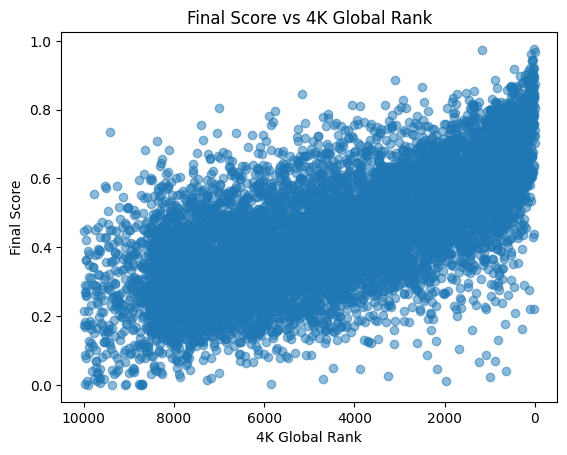

In [8]:

# Merge 4k_rank from mania_4k_rankings.csv using username or user_id
leaderboard = pd.merge(
    filtered_df,
    mania_4k_rankings[['user_id', 'global_rank']],
    on='user_id',
    how='left',
    suffixes=('', '_mania')
)

# filtered_df.drop(columns=['global_rank'], inplace=True)
print(leaderboard)

plt.scatter(leaderboard['global_rank'], leaderboard['final_score'], alpha=0.5)
plt.xlabel('4K Global Rank')
plt.ylabel('Final Score')
plt.title('Final Score vs 4K Global Rank')
plt.gca().invert_xaxis()  # Lower rank (better) on the left
plt.show()

In [9]:


# Sort by final_score descending and assign rank
leaderboard = leaderboard.sort_values(by='final_score', ascending=False)
leaderboard = leaderboard[leaderboard['adjusted_median_pScore'] != 'No Score']
leaderboard['final_rank'] = range(1, len(leaderboard) + 1)
leaderboard.to_csv('leaderboard_tournament_adjusted.csv', index=False)

